# Home assignment: PCA, t-SNE and UMAP on molecular descriptors



In [1]:
# Uncomment on Google Colab
!pip install rdkit umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 47.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness

try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors
except ImportError:
    raise ImportError("RDKit is missing. Install it with:  pip install rdkit")

try:
    import umap
    HAVE_UMAP = True
except ImportError:
    HAVE_UMAP = False
    print("umap-learn not found; UMAP cells will be skipped. Install with: pip install umap-learn")

SEED = 42

## 1. Build a small molecule dataset
Six chemical classes, generated systematically so every SMILES is valid.

In [3]:
def build_dataset():
    rows = []

    def add(smiles, cls):
        rows.append({"smiles": smiles, "class": cls})

    for n in range(1, 11):
        add("C" * n + "O", "Alcohol")
    for m in range(1, 6):
        add("CC(O)" + "C" * m, "Alcohol")

    for n in range(1, 11):
        add("C" * n + "N", "Amine")
    for m in range(1, 6):
        add("CN(C)" + "C" * m, "Amine")

    for n in range(0, 10):
        add("C" * n + "C(=O)O", "Carboxylic acid")
    for m in range(1, 6):
        add("OC(=O)" + "C" * m + "C(=O)O", "Carboxylic acid")

    for n in range(1, 11):
        add("CC(=O)" + "C" * n, "Ketone")

    for n in range(1, 9):
        add("C" * n + "Cl", "Haloalkane")
    for n in range(1, 8):
        add("C" * n + "Br", "Haloalkane")

    for n in range(0, 10):
        add("c1ccccc1" + "C" * n, "Aromatic")
    for s in ["Cc1ccc(C)cc1", "Cc1cccc(C)c1", "c1ccc2ccccc2c1",
              "c1ccc(cc1)-c1ccccc1", "c1ccc2cc3ccccc3cc2c1"]:
        add(s, "Aromatic")

    return pd.DataFrame(rows)


def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
    return {
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "MolMR": Crippen.MolMR(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "RotBonds": Descriptors.NumRotatableBonds(mol),
        "Rings": rdMolDescriptors.CalcNumRings(mol),
        "AromRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FracCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "HeavyAtoms": mol.GetNumHeavyAtoms(),
    }


df = build_dataset()
desc = pd.DataFrame([compute_descriptors(s) for s in df["smiles"]])
data = pd.concat([df, desc], axis=1)
feature_cols = list(desc.columns)
X_raw = data[feature_cols].to_numpy(dtype=float)

print(f"{len(data)} molecules, {len(feature_cols)} descriptors")
print(data["class"].value_counts())
data.head()

85 molecules, 11 descriptors
class
Alcohol            15
Amine              15
Carboxylic acid    15
Haloalkane         15
Aromatic           15
Ketone             10
Name: count, dtype: int64


,smiles,class,MolWt,LogP,MolMR,TPSA,HBD,HBA,RotBonds,Rings,AromRings,FracCSP3,HeavyAtoms
0,CO,Alcohol,32.042,-0.3915,8.1428,20.23,1,1,0,0,0,1.0,2
1,CCO,Alcohol,46.069,-0.0014,12.7598,20.23,1,1,0,0,0,1.0,3
2,CCCO,Alcohol,60.096,0.3887,17.3768,20.23,1,1,1,0,0,1.0,4
3,CCCCO,Alcohol,74.123,0.7788,21.9938,20.23,1,1,2,0,0,1.0,5
4,CCCCCO,Alcohol,88.150,1.1689,26.6108,20.23,1,1,3,0,0,1.0,6


## 2. Plotting helper

In [4]:
CLASSES = sorted(data["class"].unique())
MARKERS = ["o", "^", "s", "D", "v", "P"]
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#6250d6"]


def plot_by_class(ax, Y, title, xlabel="Dim 1", ylabel="Dim 2"):
    for cls, mk, col in zip(CLASSES, MARKERS, COLORS):
        idx = (data["class"] == cls).to_numpy()
        ax.scatter(Y[idx, 0], Y[idx, 1], marker=mk, c=col, s=35,
                   edgecolor="white", linewidth=0.5, label=cls)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


def plot_by_value(ax, Y, values, title, label):
    sc = ax.scatter(Y[:, 0], Y[:, 1], c=values, cmap="viridis", s=35,
                    edgecolor="white", linewidth=0.5)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_title(title, fontsize=10)

## 3. PCA: raw vs standardized descriptors

Explained variance ratio (raw):          [0.8178 0.1704 0.0106 0.0011]
Explained variance ratio (standardized): [0.4828 0.2881 0.174  0.0224]


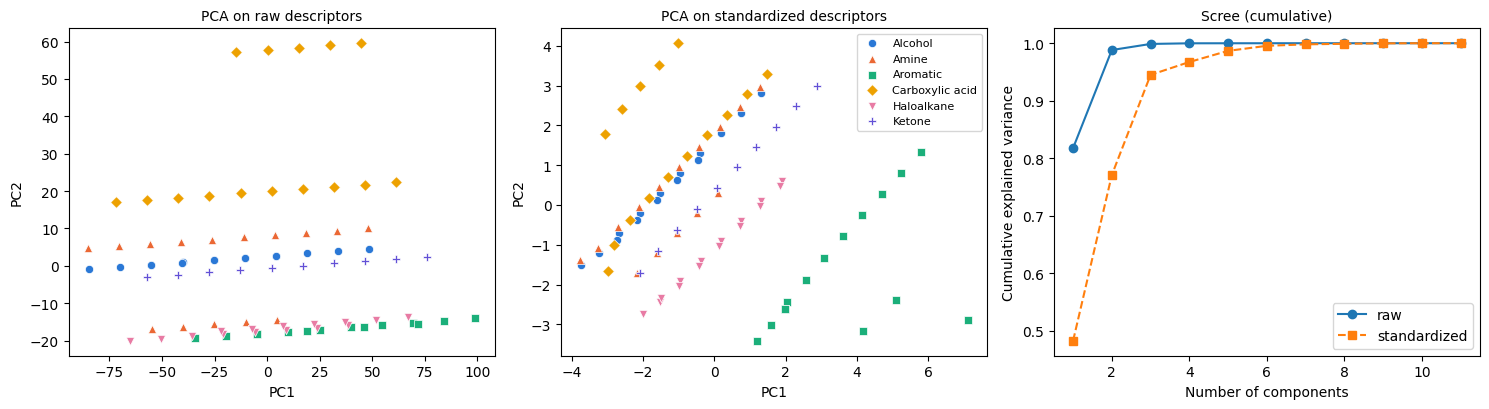

In [5]:
X_std = StandardScaler().fit_transform(X_raw)

pca_raw = PCA().fit(X_raw - X_raw.mean(axis=0))
pca_std = PCA().fit(X_std)

print("Explained variance ratio (raw):         ", np.round(pca_raw.explained_variance_ratio_[:4], 4))
print("Explained variance ratio (standardized):", np.round(pca_std.explained_variance_ratio_[:4], 4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
Y_raw = pca_raw.transform(X_raw - X_raw.mean(axis=0))[:, :2]
Y_pca = pca_std.transform(X_std)[:, :2]
plot_by_class(axes[0], Y_raw, "PCA on raw descriptors", "PC1", "PC2")
plot_by_class(axes[1], Y_pca, "PCA on standardized descriptors", "PC1", "PC2")

k = np.arange(1, len(feature_cols) + 1)
axes[2].plot(k, np.cumsum(pca_raw.explained_variance_ratio_), "o-", label="raw")
axes[2].plot(k, np.cumsum(pca_std.explained_variance_ratio_), "s--", label="standardized")
axes[2].set_xlabel("Number of components")
axes[2].set_ylabel("Cumulative explained variance")
axes[2].set_title("Scree (cumulative)", fontsize=10)
axes[2].legend()
axes[1].legend(fontsize=8, loc="best")
plt.tight_layout()
plt.savefig("fig1_pca.png", dpi=150)
plt.show()

### PCA loadings (standardized)

In [6]:
loadings = pd.DataFrame(pca_std.components_[:2].T, index=feature_cols, columns=["PC1", "PC2"])
print(loadings.round(3).sort_values("PC1", key=abs, ascending=False))

              PC1    PC2
LogP        0.404  0.116
MolMR       0.389  0.239
HeavyAtoms  0.355  0.297
MolWt       0.348  0.295
Rings       0.319 -0.246
AromRings   0.319 -0.246
HBA        -0.252  0.360
HBD        -0.231  0.320
TPSA       -0.211  0.360
FracCSP3   -0.195  0.205
RotBonds    0.187  0.480


### YOUR TURN (B1)
1. Why does raw-data PCA give a very high PC1 explained variance? Which descriptor dominates?
2. Using the loadings, give a chemical name to PC1 and PC2 of the standardized PCA.
3. How many components are needed to reach 90% of the variance (standardized)?

In [7]:
n90 = int(np.searchsorted(np.cumsum(pca_std.explained_variance_ratio_), 0.90) + 1)
print("Components needed for 90% variance (standardized):", n90)

Components needed for 90% variance (standardized): 3


In [8]:
# B1: raw descriptor variances and raw PCA loadings
print("Variance of raw descriptors:")
print(pd.Series(X_raw.var(axis=0, ddof=1), index=feature_cols).sort_values(ascending=False).round(2))
raw_load = pd.DataFrame(pca_raw.components_[:2].T, index=feature_cols, columns=["PC1", "PC2"])
print("\nRaw-PCA loadings:")
print(raw_load.round(3).sort_values("PC1", key=abs, ascending=False))

Variance of raw descriptors:
MolWt         1623.24
TPSA           372.21
MolMR          184.52
HeavyAtoms       9.65
RotBonds         6.73
LogP             1.59
HBD              0.37
HBA              0.33
Rings            0.29
AromRings        0.29
FracCSP3         0.09
dtype: float64

Raw-PCA loadings:
              PC1    PC2
MolWt       0.949  0.067
MolMR       0.301 -0.083
HeavyAtoms  0.067  0.018
RotBonds    0.048  0.035
TPSA       -0.041  0.992
LogP        0.026 -0.026
Rings       0.004 -0.010
AromRings   0.004 -0.010
HBD        -0.003  0.028
HBA        -0.003  0.025
FracCSP3   -0.001  0.000


Answer:

1. The raw descriptors are on very different scales. MolWt has the largest variance (1620, compared with 370 for TPSA and <10 for most others), so PC1 is basically just MolWt (loading 0.95). PC2 is basically TPSA. So the 82% on PC1 comes from the units, not from real structure in the data.

2. PC1 (48%) is a size/lipophilicity axis: LogP, MolMR, HeavyAtoms, MolWt and rings load positive, while polar descriptors load negative. PC2 (29%) is a polarity/flexibility axis: RotBonds, HBA, HBD and TPSA load positive and aromatic rings load negative.

3. 3 components (48% then 77% then 94.5%).

## 4. t-SNE: effect of perplexity and random seed

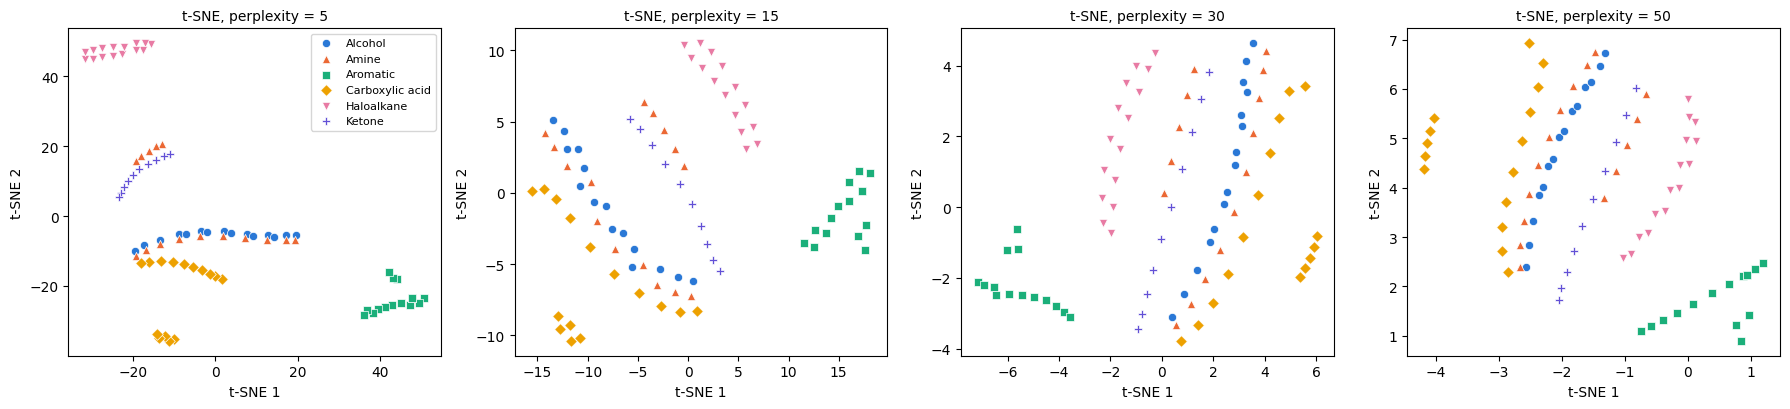

In [9]:
perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(1, len(perplexities), figsize=(18, 4.2))
tsne_results = {}
for ax, p in zip(axes, perplexities):
    Y = TSNE(n_components=2, perplexity=p, init="pca", learning_rate="auto",
             random_state=SEED).fit_transform(X_std)
    tsne_results[p] = Y
    plot_by_class(ax, Y, f"t-SNE, perplexity = {p}", "t-SNE 1", "t-SNE 2")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig2_tsne_perplexity.png", dpi=150)
plt.show()

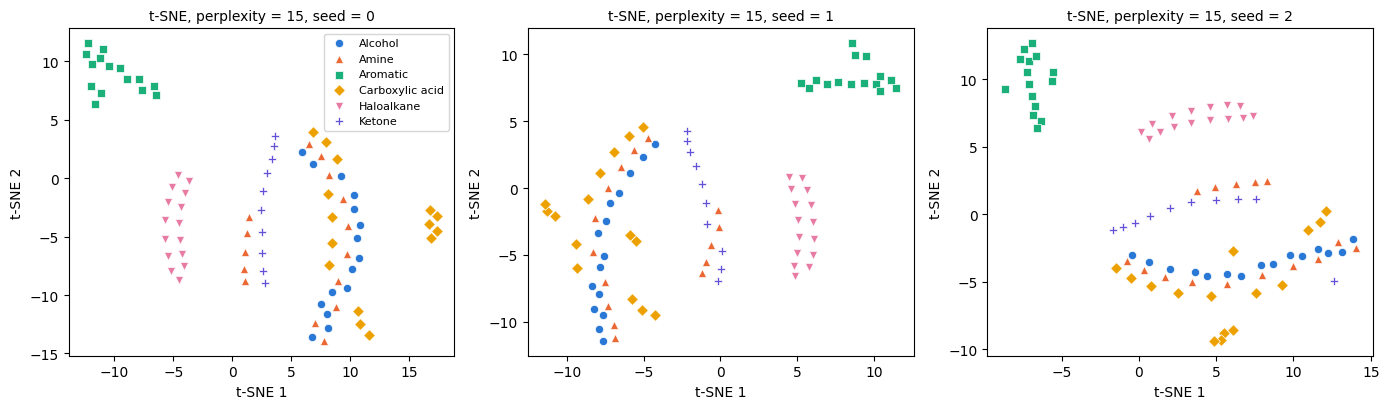

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, seed in zip(axes, [0, 1, 2]):
    Y = TSNE(n_components=2, perplexity=15, init="random", learning_rate="auto",
             random_state=seed).fit_transform(X_std)
    plot_by_class(ax, Y, f"t-SNE, perplexity = 15, seed = {seed}", "t-SNE 1", "t-SNE 2")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig3_tsne_seeds.png", dpi=150)
plt.show()

### YOUR TURN (B2)
1. How does the map change as perplexity increases from 5 to 50?
2. Which features stay the same across seeds, and which change?
3. Why is perplexity = 100 not allowed for this dataset?

In [11]:
# B2.3: perplexity = 100 fails
try:
    TSNE(n_components=2, perplexity=100, random_state=SEED).fit_transform(X_std)
except ValueError as e:
    print("ValueError:", e)

ValueError: perplexity must be less than n_samples


**Answers (B2)**

1. At perplexity 5 the map is very local: each series is a tight separate string, and some classes split further (e.g. the diacids separate from the monoacids). As perplexity goes up, the clusters come closer and the map becomes more global. At 50 it is compressed and starts looking like the PCA layout.

2. The local neighbourhoods stay the same. Each homologous series stays a chain, aromatics and haloalkanes stay separate, and alcohols and amines always overlap. The position, rotation and spacing of the clusters change with the seed, so distances between clusters shouldn't be interpreted.

3. There are only 85 molecules, and perplexity has to be less than the number of samples (the cell above gives a ValueError).

## 5. UMAP: effect of n_neighbors and min_dist

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


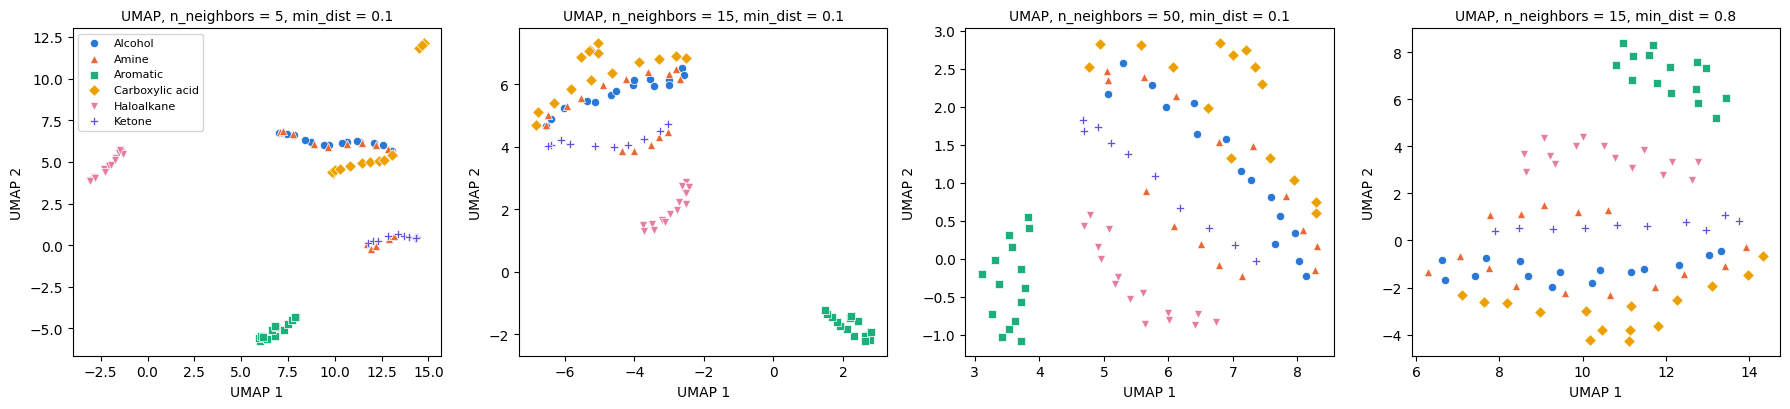

In [12]:
umap_results = {}
if HAVE_UMAP:
    settings = [(5, 0.1), (15, 0.1), (50, 0.1), (15, 0.8)]
    fig, axes = plt.subplots(1, len(settings), figsize=(18, 4.2))
    for ax, (nn, md) in zip(axes, settings):
        Y = umap.UMAP(n_neighbors=nn, min_dist=md, random_state=SEED).fit_transform(X_std)
        umap_results[(nn, md)] = Y
        plot_by_class(ax, Y, f"UMAP, n_neighbors = {nn}, min_dist = {md}", "UMAP 1", "UMAP 2")
    axes[0].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("fig4_umap.png", dpi=150)
    plt.show()

### YOUR TURN (B3)
1. Compare n_neighbors = 5 and 50. Which shows more local detail, which more global layout?
2. What does increasing min_dist from 0.1 to 0.8 do to the clusters?

Answer:

1. n_neighbors = 5 shows more local detail sharp lines broken into separate islands. n_neighbors = 50 keeps the aromatics at one side, the polar classes together, similar to PCA, but the lines are noisier.

2. The clusters spread out and become more diffuse. The tight lines turn into loose bands, and the classes overlap more.

## 6. Colour by a continuous property

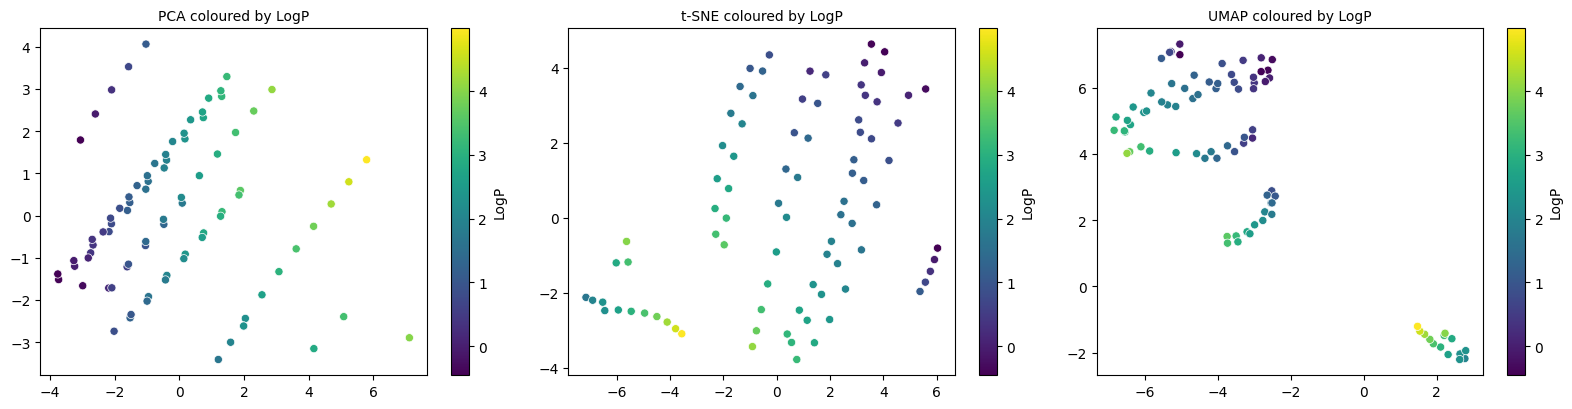

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
plot_by_value(axes[0], Y_pca, data["LogP"], "PCA coloured by LogP", "LogP")
plot_by_value(axes[1], tsne_results[30], data["LogP"], "t-SNE coloured by LogP", "LogP")
if HAVE_UMAP:
    plot_by_value(axes[2], umap_results[(15, 0.1)], data["LogP"], "UMAP coloured by LogP", "LogP")
else:
    axes[2].axis("off")
plt.tight_layout()
plt.savefig("fig5_logp.png", dpi=150)
plt.show()

### YOUR TURN (B4)
Inside each class cluster, is there a smooth LogP gradient? What structural change
(hint: chain length) produces it?

Answer:

Yes In every class LogP increases smoothly along the cluster. This is because each class is a homologous series, and every extra CH2 adds about 0.39 to LogP (MeOH −0.39, EtOH 0.00, PrOH 0.39...), with MolWt and MolMR increasing along with it. In PCA the gradeint lies roughly along PC1. In t-SNE/UMAP it is only consistent within each cluster, not across the whole map.

## 7. Quantitative comparison: trustworthiness
Trustworthiness (0 to 1) measures how well each point's nearest neighbours in the map
were also neighbours in the original space. 1 means perfect local preservation.

In [14]:
emb = {"PCA (2 PCs)": Y_pca, "t-SNE (perp 30)": tsne_results[30]}
if HAVE_UMAP:
    emb["UMAP (nn 15)"] = umap_results[(15, 0.1)]

for k_nn in [5, 15]:
    for name, Y in emb.items():
        t = trustworthiness(X_std, Y, n_neighbors=k_nn)
        print(f"k = {k_nn:2d}  {name:18s} trustworthiness = {t:.3f}")

k =  5  PCA (2 PCs)        trustworthiness = 0.986
k =  5  t-SNE (perp 30)    trustworthiness = 0.996
k =  5  UMAP (nn 15)       trustworthiness = 0.991
k = 15  PCA (2 PCs)        trustworthiness = 0.981
k = 15  t-SNE (perp 30)    trustworthiness = 0.971
k = 15  UMAP (nn 15)       trustworthiness = 0.936


### YOUR TURN (B5)
1. Which method preserves local neighbourhoods best? Is that what you expected?
2. Trustworthiness says nothing about distances between clusters. Propose a check
   for global structure (hint: correlate pairwise distances in the original and 2D spaces).

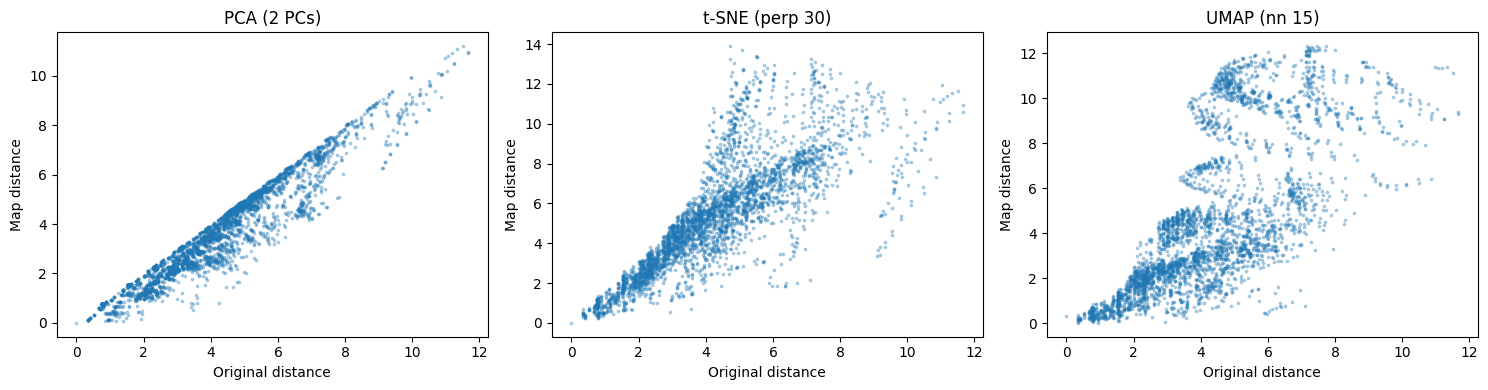

In [16]:
from scipy.spatial.distance import pdist

D_high = pdist(X_std)
fig, axes = plt.subplots(1, len(emb), figsize=(5 * len(emb), 4))
for ax, (name, Y) in zip(np.atleast_1d(axes), emb.items()):
    D_low = pdist(Y)
    ax.scatter(D_high, D_low, s=3, alpha=0.3)
    ax.set_xlabel("Original distance")
    ax.set_ylabel("Map distance")
    ax.set_title(name)
plt.tight_layout()
plt.show()

Answer:

1. t-SNE preserves local neighborhoods best at k = 5, which is expected because it is designed to optimize local structures.

2. We can plot and compare the distances between points in the original space against their distances in the 2D map to see if they line up.